<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Kuis_01/K_Means_Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Manhattan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# BAGIAN A: LOAD DATA & PREPROCESSING

# Load dataset (separator TAB)
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Pilih fitur numerik yang relevan
kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

# Encoding jika ada kolom teks
kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

# Standardisasi
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

# L2 Normalization untuk Cosine (tidak dipakai di sini, tapi disiapkan)
from sklearn.preprocessing import Normalizer
X_l2 = Normalizer(norm='l2').fit_transform(X_scaled)

print(f"Data siap | Shape: {X_scaled.shape} | Baris: {len(df_fitur)}")

Data siap | Shape: (2216, 16) | Baris: 2216


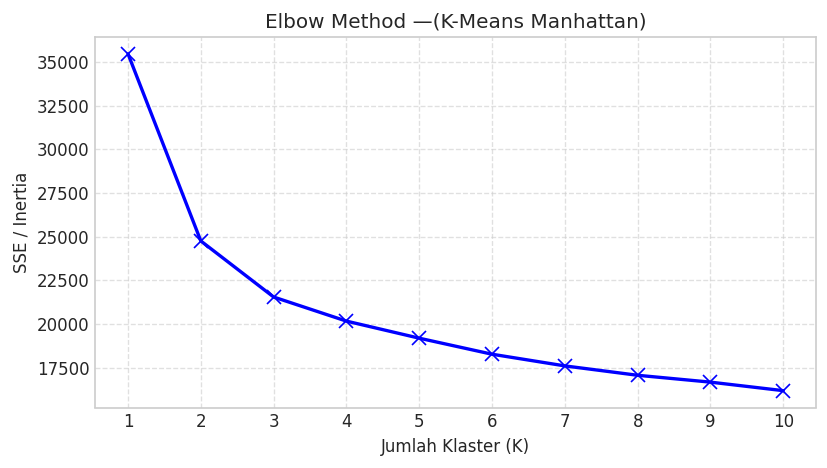

In [37]:
# BAGIAN B: ELBOW METHOD (untuk menentukan K terbaik)

K_range = range(1, 11)
sse     = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sse, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method —(K-Means Manhattan)')
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('a1_elbow.png')
plt.show()

K_TERBAIK = 4  # Ganti sesuai hasil elbow

In [48]:
# BAGIAN D: K-MEANS MANHATTAN — Latih + Ukur Performa

print("\n" + "="*52)
print("  K-MEANS — METRIK: MANHATTAN")
print("="*52)

tracemalloc.start()
t_mulai = time.time()

# PERBAIKAN: Menggunakan KMeansManhattan
km_manhattan  = KMeansManhattan(n_clusters=K_TERBAIK, random_state=42)
lbl_manhattan = km_manhattan.fit_predict(X_scaled)

t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Silhouette pakai metric manhattan
sil_manhattan = silhouette_score(X_scaled, lbl_manhattan, metric='manhattan')

# PENAMBAHAN: Metrik evaluasi pelengkap (seperti pada kode dosen)
db_score = davies_bouldin_score(X_scaled, lbl_manhattan)
ch_score = calinski_harabasz_score(X_scaled, lbl_manhattan)

print(f"  Jumlah Klaster        : {K_TERBAIK}")
print(f"  Waktu Eksekusi        : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak         : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score      : {sil_manhattan:.4f}")
print(f"  Davies-Bouldin Index  : {db_score:.4f}")
print(f"  Calinski-Harabasz     : {ch_score:.2f}")
print(f"  SAE (Inertia L1)      : {km_manhattan.inertia_:.2f}")
print("="*52)


  K-MEANS — METRIK: MANHATTAN
  Jumlah Klaster        : 4
  Waktu Eksekusi        : 0.3000 detik
  Memori Puncak         : 411.19 KB (0.4016 MB)
  Silhouette Score      : 0.2563
  Davies-Bouldin Index  : 2.3866
  Calinski-Harabasz     : 498.05
  SAE (Inertia L1)      : 17334.63


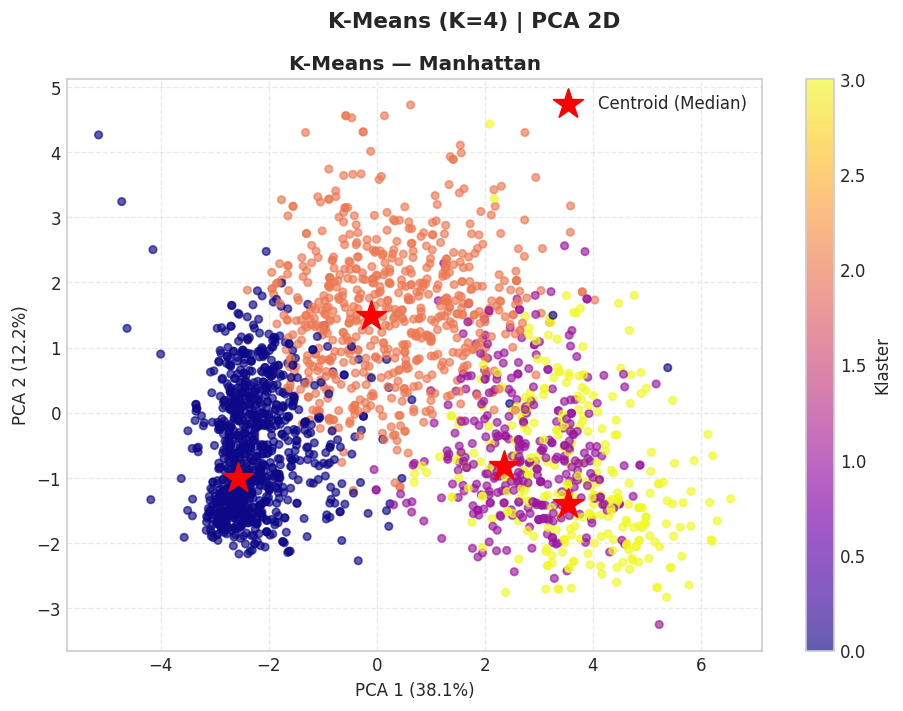

Visualisasi disimpan: 'a1_kmeans_plot.png'


In [49]:
# BAGIAN E: VISUALISASI PCA (Manhattan)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
v1, v2 = pca.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle(f'K-Means (K={K_TERBAIK}) | PCA 2D', fontsize=13, fontweight='bold')

# Plot Manhattan
sc2 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_manhattan,
                  cmap='plasma', s=20, alpha=0.65)

# PERBAIKAN: Menggunakan km_manhattan.centroids (Pusat Median Manhattan)
cen2 = pca.transform(km_manhattan.centroids)
ax1.scatter(cen2[:, 0], cen2[:, 1], c='red', marker='*', s=350, zorder=5, label='Centroid (Median)')
ax1.set_title('K-Means — Manhattan', fontweight='bold')
ax1.set_xlabel(f'PCA 1 ({v1:.1f}%)')
ax1.set_ylabel(f'PCA 2 ({v2:.1f}%)')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc2, ax=ax1, label='Klaster')

plt.tight_layout()
plt.savefig('a1_kmeans_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a1_kmeans_plot.png'")